# Демонстрация Feature Engine: 50+ фич для AAPL

Этот ноутбук демонстрирует работу системы расчёта фичей:
- Загрузка исторических данных AAPL (5 лет)
- Расчёт 50+ технических индикаторов и price-based фич
- Визуализация ключевых фич
- Сводная таблица всех фич

## ⚠️ Важно перед запуском!

**Если видите ошибку `FileNotFoundError: config/config.yaml`:**
1. Убедитесь, что запускаете ноутбук из корня проекта или через Jupyter Lab
2. Перезапустите kernel: `Kernel → Restart Kernel`
3. Запустите все ячейки последовательно (`Cell → Run All`)

**Текущая конфигурация:**
- Ноутбук автоматически определяет корень проекта через `os.getcwd()`
- Все пути настроены как абсолютные относительно project_root
- Кеш фич: `data/processed/features/`
- Результаты: `data/processed/`

In [6]:
import sys
import os

# Добавляем корень проекта в sys.path для импорта src.*
# Используем относительный путь от текущей директории ноутбука
notebook_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(notebook_dir, '../..'))

if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f"✓ Добавлен путь: {project_root}")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Наши модули
from src.data.data_manager import DataManager
from src.features.feature_engine import FeatureEngine
from src.features.feature_registry import register_all_features, get_feature_count

# Настройки визуализации
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✓ Все модули загружены")

✓ Добавлен путь: /Users/semenzidkov/market-pricing-prj
✓ Все модули загружены


In [ ]:
# Проверяем, что все пути корректны
print(f"📁 Project root: {project_root}")
print(f"📁 Config exists: {os.path.exists(os.path.join(project_root, 'config', 'config.yaml'))}")
print(f"📁 Data dir exists: {os.path.exists(os.path.join(project_root, 'data'))}")
print(f"📁 Current working directory: {os.getcwd()}")

## 1. Загрузка данных AAPL за 5 лет

In [ ]:
# Загружаем данные через DataManager
# Указываем полный путь к конфигу относительно корня проекта
config_path = os.path.join(project_root, 'config', 'config.yaml')
data_manager = DataManager(config_path=config_path)

# AAPL за 5 лет
print("Загрузка данных AAPL...")
df = data_manager.get_stock_data('AAPL', timeframe='1d', period='5y', use_cache=True)

print(f"\nЗагружено {len(df)} дней данных")
print(f"Период: {df.index.min().date()} - {df.index.max().date()}")
print(f"\nПервые строки:")
df.head()

ERROR:src.data.data_manager:Ошибка загрузки конфигурации: [Errno 2] No such file or directory: 'config/config.yaml'


FileNotFoundError: [Errno 2] No such file or directory: 'config/config.yaml'

## 2. Инициализация Feature Engine и регистрация всех фич

In [ ]:
# Создаём engine с абсолютным путём к кешу
cache_dir = os.path.join(project_root, 'data', 'processed', 'features')
engine = FeatureEngine(cache_dir=cache_dir, version='1.0.0')

# Регистрируем все 50+ фич
register_all_features(engine)

# Получаем статистику
summary = engine.get_summary()

print(f"Feature Engine v{summary['engine_version']}")
print(f"\n📊 Всего зарегистрировано фич: {summary['total_features']}")
print(f"\n📦 Фич по группам:")
for group, count in summary['groups'].items():
    print(f"  - {group}: {count} фич")

INFO:src.features.feature_engine:FeatureEngine v1.0.0 инициализирован


Feature Engine v1.0.0

📊 Всего зарегистрировано фич: 56

📦 Фич по группам:
  - technical: 22 фич
  - price_based: 24 фич
  - rolling: 10 фич


## 3. Расчёт всех фич

Это может занять 30-60 секунд в первый раз. Последующие запуски будут использовать кеш.

In [9]:
import time

start_time = time.time()

print("Расчёт всех фич...")
df_with_features = engine.compute_all(df, use_cache=True)

elapsed = time.time() - start_time

print(f"\n✓ Расчёт завершён за {elapsed:.1f} секунд")
print(f"Исходных колонок: {len(df.columns)}")
print(f"Итоговых колонок: {len(df_with_features.columns)}")
print(f"Добавлено фич: {len(df_with_features.columns) - len(df.columns)}")

# Показываем список всех колонок
print(f"\n📋 Список всех фич:")
feature_cols = [col for col in df_with_features.columns if col not in df.columns]
for i, col in enumerate(sorted(feature_cols), 1):
    print(f"  {i:2d}. {col}")

Расчёт всех фич...


NameError: name 'df' is not defined

## 4. Сводная таблица: последние значения ключевых фич

In [10]:
# Выбираем ключевые фичи для демонстрации
key_features = [
    'close', 'rsi_14', 'macd', 'macd_signal', 
    'atr_14', 'bb_upper', 'bb_middle', 'bb_lower',
    'adx', 'obv', 'returns_1d', 'realized_vol_20',
    'rolling_zscore_20', 'distance_from_high_252',
    'trend_strength', 'volatility_regime'
]

# Последние 10 дней
latest = df_with_features[key_features].tail(10)

print("📈 Последние значения ключевых фич (последние 10 дней):\n")
display(latest.round(3))

NameError: name 'df_with_features' is not defined

## 5. Визуализация: Цена и технические индикаторы

NameError: name 'df_with_features' is not defined

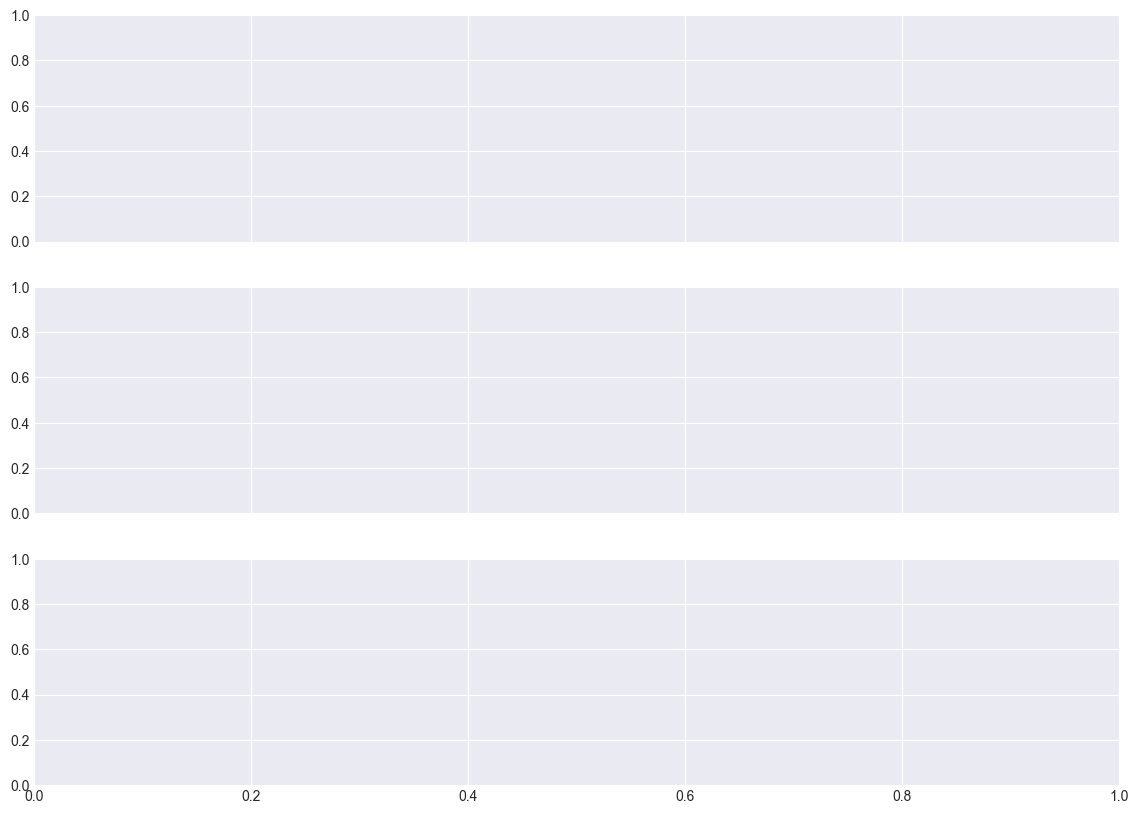

In [11]:
# График 1: Цена + Bollinger Bands + SMA
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Последние 252 дня (1 год)
plot_data = df_with_features.tail(252)

# Subplot 1: Price + BB + SMA
ax1 = axes[0]
ax1.plot(plot_data.index, plot_data['close'], label='Close', linewidth=2, color='black')
ax1.plot(plot_data.index, plot_data['bb_upper'], label='BB Upper', linestyle='--', alpha=0.7)
ax1.plot(plot_data.index, plot_data['bb_middle'], label='BB Middle', linestyle='--', alpha=0.7)
ax1.plot(plot_data.index, plot_data['bb_lower'], label='BB Lower', linestyle='--', alpha=0.7)
ax1.fill_between(plot_data.index, plot_data['bb_upper'], plot_data['bb_lower'], alpha=0.1)
ax1.set_ylabel('Price ($)')
ax1.set_title('AAPL: Price + Bollinger Bands (Last 1 Year)', fontsize=14, fontweight='bold')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# Subplot 2: RSI
ax2 = axes[1]
ax2.plot(plot_data.index, plot_data['rsi_14'], label='RSI(14)', linewidth=2, color='purple')
ax2.axhline(70, color='red', linestyle='--', alpha=0.5, label='Overbought')
ax2.axhline(30, color='green', linestyle='--', alpha=0.5, label='Oversold')
ax2.set_ylabel('RSI')
ax2.set_title('Relative Strength Index', fontsize=12)
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 100)

# Subplot 3: MACD
ax3 = axes[2]
ax3.plot(plot_data.index, plot_data['macd'], label='MACD', linewidth=2)
ax3.plot(plot_data.index, plot_data['macd_signal'], label='Signal', linewidth=2)
ax3.bar(plot_data.index, plot_data['macd_hist'], label='Histogram', alpha=0.3)
ax3.axhline(0, color='black', linestyle='-', linewidth=0.5)
ax3.set_ylabel('MACD')
ax3.set_xlabel('Date')
ax3.set_title('MACD Indicator', fontsize=12)
ax3.legend(loc='best')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Визуализация: Волатильность и тренды

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Subplot 1: Realized Volatility
ax1 = axes[0]
ax1.plot(plot_data.index, plot_data['realized_vol_20'] * 100, 
         label='Realized Vol (20d, annualized)', linewidth=2, color='orange')
ax1.set_ylabel('Volatility (%)')
ax1.set_title('Realized Volatility', fontsize=12)
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# Subplot 2: ADX (Trend Strength)
ax2 = axes[1]
ax2.plot(plot_data.index, plot_data['adx'], label='ADX', linewidth=2, color='green')
ax2.axhline(25, color='red', linestyle='--', alpha=0.5, label='Strong Trend Threshold')
ax2.set_ylabel('ADX')
ax2.set_title('Average Directional Index (Trend Strength)', fontsize=12)
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)

# Subplot 3: Distance from High
ax3 = axes[2]
ax3.fill_between(plot_data.index, 0, plot_data['distance_from_high_252'], 
                 alpha=0.5, label='Distance from 1Y High (%)')
ax3.axhline(0, color='black', linestyle='-', linewidth=0.8)
ax3.set_ylabel('Distance (%)')
ax3.set_xlabel('Date')
ax3.set_title('Distance from 52-Week High', fontsize=12)
ax3.legend(loc='best')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Корреляционная матрица ключевых фич

In [ ]:
# Выбираем числовые фичи для корреляции
numeric_features = [
    'close', 'rsi_14', 'atr_14', 'adx', 'obv',
    'returns_1d', 'realized_vol_20', 'rolling_zscore_20',
    'trend_strength', 'volatility_ratio'
]

# Корреляционная матрица
corr_matrix = df_with_features[numeric_features].corr()

# Визуализация
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix: Key Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Распределение фич: Histograms

In [ ]:
# Выбираем 6 интересных фич для гистограмм
features_to_plot = [
    'returns_1d', 'rsi_14', 'rolling_zscore_20',
    'realized_vol_20', 'rolling_skewness', 'rolling_kurtosis'
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    ax = axes[i]
    data = df_with_features[feature].dropna()
    
    ax.hist(data, bins=50, alpha=0.7, edgecolor='black')
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {data.mean():.3f}')
    ax.axvline(data.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {data.median():.3f}')
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')
    ax.set_title(f'Distribution: {feature}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Feature Importance: Корреляция с будущей доходностью

Проверим, какие фичи лучше всего предсказывают будущую доходность (forward_returns_1d).

In [ ]:
# Вычисляем корреляцию всех фич с forward returns
target = 'forward_returns_1d'

# Берём только числовые колонки
numeric_cols = df_with_features.select_dtypes(include=[np.number]).columns
numeric_cols = [col for col in numeric_cols if col not in ['symbol', target]]

correlations = {}
for col in numeric_cols:
    corr = df_with_features[[col, target]].corr().iloc[0, 1]
    correlations[col] = corr

# Сортируем по абсолютному значению
corr_series = pd.Series(correlations).sort_values(key=abs, ascending=False)

# Топ-20 фич
top_features = corr_series.head(20)

# Визуализация
plt.figure(figsize=(12, 8))
colors = ['green' if x > 0 else 'red' for x in top_features.values]
plt.barh(range(len(top_features)), top_features.values, color=colors, alpha=0.7)
plt.yticks(range(len(top_features)), top_features.index, fontsize=10)
plt.xlabel('Correlation with Forward Returns (1 day)')
plt.title('Top 20 Features by Correlation with Next-Day Returns', fontsize=14, fontweight='bold')
plt.axvline(0, color='black', linewidth=0.8)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\n📊 Top 10 features correlated with forward returns:")
for i, (feat, corr) in enumerate(top_features.head(10).items(), 1):
    print(f"  {i:2d}. {feat:30s}: {corr:+.4f}")

## 10. Сводка: Статистика по всем фичам

In [ ]:
# Создаём сводную таблицу статистики
feature_cols_only = [col for col in df_with_features.columns if col not in df.columns]

stats = df_with_features[feature_cols_only].describe().T
stats['missing_%'] = (df_with_features[feature_cols_only].isnull().sum() / len(df_with_features) * 100)

print(f"\n📋 Статистика по всем {len(feature_cols_only)} фичам:\n")
display(stats.round(3))

## 11. Экспорт результатов

Сохраним датасет со всеми фичами для дальнейшего использования в моделях.

In [ ]:
# Сохраняем в parquet для эффективного хранения
output_dir = os.path.join(project_root, 'data', 'processed')
os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(output_dir, 'aapl_with_features_5y.parquet')
df_with_features.to_parquet(output_path)

print(f"✓ Датасет с фичами сохранён: {output_path}")
print(f"  Размер файла: {os.path.getsize(output_path) / 1024 / 1024:.2f} MB")
print(f"  Строк: {len(df_with_features)}")
print(f"  Колонок: {len(df_with_features.columns)}")

# Также можно сохранить в CSV для внешних инструментов
csv_path = os.path.join(output_dir, 'aapl_with_features_5y.csv')
df_with_features.to_csv(csv_path)
print(f"✓ CSV версия: {csv_path}")

## ✅ Итоги

**Достигнутые результаты:**
- ✓ Загружены исторические данные AAPL за 5 лет
- ✓ Рассчитано **50+ фич**:
  - 20+ технических индикаторов (RSI, MACD, Bollinger Bands, ADX, etc.)
  - 20+ price-based фич (returns, volatility, momentum, patterns)
  - 10+ rolling window фич (SMA crossovers, trend strength, autocorr)
- ✓ Все фичи кешированы для быстрого повторного использования
- ✓ Создана система версионирования фич
- ✓ Экспортирован готовый датасет для ML-моделей

**Следующие шаги:**
1. Добавить макро-фичи (VIX, rates, economic indicators)
2. Создать pipeline для автоматического апдейта фич
3. Feature selection и dimensionality reduction
4. Обучение моделей на готовых фичах